# Escalonadores — tempo médio ± desvio padrão

Dois gráficos separados (CPU-bound e IO-bound), comparando `round-robin/`, `baseline/` e `multiplas-filas/`.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

N_PROCESSOS = [10, 50, 100, 200, 300]
FONTES = {
    "Round-Robin": ("round-robin", "resultados_rr_{n_processos}.txt"),
    "Padrão MINIX": ("baseline", "resultados_bl_{n_processos}.txt"),
    "Múltiplas filas": ("multiplas-filas", "resultados_mf_{n_processos}.txt"),
}


def carregar(pasta: Path, padrao: str) -> pd.DataFrame:
    frames = []
    for processo in N_PROCESSOS:
        df = pd.read_csv(
            pasta / padrao.format(n_processos=processo),
            sep="\t",
            header=None,
            names=["tipo", "pid", "tempo"],
            skipinitialspace=True,
        )
        df["n_processos"] = processo
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


frames = []
for algoritmo, (pasta, padrao) in FONTES.items():
    df = carregar(Path(pasta), padrao)
    df["algoritmo"] = algoritmo
    frames.append(df)

dados = pd.concat(frames, ignore_index=True)
dados["n_processos"] = pd.Categorical(dados["n_processos"], categories=N_PROCESSOS, ordered=True)
dados["algoritmo"] = pd.Categorical(
    dados["algoritmo"], categories=list(FONTES.keys()), ordered=True
)

cpu = dados[dados["tipo"] == "CPU"].copy()
io = dados[dados["tipo"] == "IO"].copy()

cpu.head(), io.head()

(  tipo  pid  tempo n_processos    algoritmo
 0  CPU    1    0.0          10  Round-Robin
 1  CPU    3    0.0          10  Round-Robin
 2  CPU    5    0.0          10  Round-Robin
 3  CPU    7    0.0          10  Round-Robin
 4  CPU    9    0.0          10  Round-Robin,
   tipo  pid    tempo n_processos    algoritmo
 5   IO    0  20.0667          10  Round-Robin
 6   IO    2  20.0667          10  Round-Robin
 7   IO    4  20.0667          10  Round-Robin
 8   IO    6  20.0833          10  Round-Robin
 9   IO    8  20.0833          10  Round-Robin)

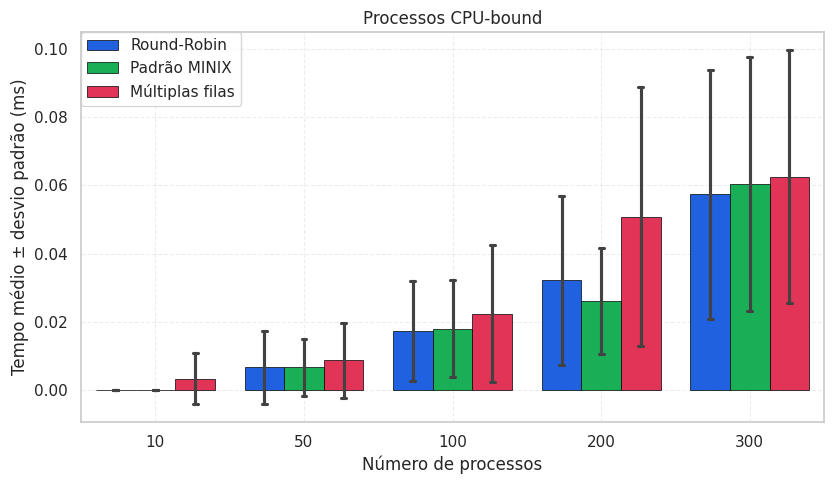

In [4]:
PALETA = {
    "Round-Robin": "#0057FF",
    "Padrão MINIX": "#00C853",
    "Múltiplas filas": "#FF1744",
}


def plotar_barras(data: pd.DataFrame, titulo: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=data,
        x="n_processos",
        y="tempo",
        hue="algoritmo",
        palette=PALETA,
        errorbar="sd",
        capsize=0.1,
        linewidth=0.5,
        edgecolor="black",
        ax=ax,
    )

    ax.set_title(titulo)
    ax.set_xlabel("Número de processos")
    ax.set_ylabel("Tempo médio ± desvio padrão (ms)")
    ax.legend(loc="upper left", borderaxespad=0)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


plotar_barras(cpu, "Processos CPU-bound")

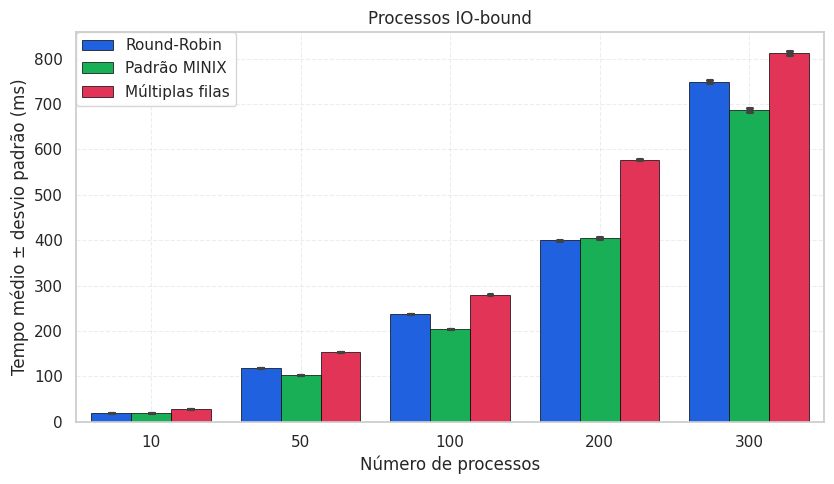

In [5]:
plotar_barras(io, "Processos IO-bound")